# Week 8: Recurrent Neural Networks for NLP



In [39]:
# ── Install any missing packages ──
# Only run this if you are on a fresh Google Colab environment
# Remove the # at the start of the line below, run it once, then add it back

# !pip install tensorflow scikit-learn spacy --quiet
# !python -m spacy download en_core_web_sm --quiet

#print("Environment ready ✓")


In [2]:
# ── Import all the tools we need for this entire session ──
# We load everything at the top so it is available throughout the notebook

import numpy as np
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

# TensorFlow / Keras — the main library for building neural networks
import tensorflow as tf
from tensorflow.keras.datasets import imdb
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding, LSTM, GRU, Bidirectional, Dense, Dropout
from tensorflow.keras.callbacks import EarlyStopping

# Scikit-learn — for the baseline TF-IDF model
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score

print(f"TensorFlow version: {tf.__version__}")
print("All imports successful ✓")

TensorFlow version: 2.20.0
All imports successful ✓


### 1.1 Load the IMDB Dataset

The **IMDB dataset** contains 50,000 movie reviews — each labelled as either **Positive (1)** or **Negative (0)**.  
It is one of the most well-known benchmark datasets in NLP.

- **25,000 reviews** for training (the model learns from these)
- **25,000 reviews** for testing (used only to measure final performance — never seen during training)


In [3]:
# ── Load the IMDB dataset ──
# num_words=10000 means we only keep the 10,000 most common words
# Rare words (unusual names, typos) are dropped — this keeps the model focused

print("Loading IMDB dataset...")
NUM_WORDS = 10000

(X_train_seq, y_train), (X_test_seq, y_test) = imdb.load_data(num_words=NUM_WORDS)

print(f"Training reviews : {len(X_train_seq):,}")
print(f"Test reviews     : {len(X_test_seq):,}")
print(f"\nSample label     : {y_train[0]}  →  {'POSITIVE' if y_train[0] == 1 else 'NEGATIVE'}")
print(f"Sample review    : {X_train_seq[0][:10]}... (these numbers represent words)")
print("\nNote: Each word has been replaced with a number.")
print("  Number 1 = most common word, number 2 = second most common, etc.")


Loading IMDB dataset...
Training reviews : 25,000
Test reviews     : 25,000

Sample label     : 1  →  POSITIVE
Sample review    : [1, 14, 22, 16, 43, 530, 973, 1622, 1385, 65]... (these numbers represent words)

Note: Each word has been replaced with a number.
  Number 1 = most common word, number 2 = second most common, etc.


In [34]:
# Convert to DataFrame and show head
import pandas as pd

df = pd.DataFrame({
    "label"  : ["POSITIVE" if y == 1 else "NEGATIVE" for y in y_train],
    "review" : [decode_review(seq)[:100] for seq in X_train_seq]
})

df.head()

,label,review
0,POSITIVE,? this film was just brilliant casting locatio...
1,NEGATIVE,? big hair big boobs bad music and a giant saf...
2,NEGATIVE,? this has to be one of the worst films of the...
3,POSITIVE,? the ? ? at storytelling the traditional sort...
4,NEGATIVE,? worst mistake of my life br br i picked this...


In [35]:
pd.set_option('display.max_colwidth', None)

df.head()

,label,review
0,POSITIVE,? this film was just brilliant casting location scenery story direction everyone's really suited the
1,NEGATIVE,? big hair big boobs bad music and a giant safety pin these are the words to best describe this terr
2,NEGATIVE,? this has to be one of the worst films of the 1990s when my friends i were watching this film being
3,POSITIVE,? the ? ? at storytelling the traditional sort many years after the event i can still see in my ? ey
4,NEGATIVE,? worst mistake of my life br br i picked this movie up at target for 5 because i figured hey it's s


In [36]:
# Rebuild df with FULL review text (no limit)
df = pd.DataFrame({
    "label"  : ["POSITIVE" if y == 1 else "NEGATIVE" for y in y_train],
    "review" : [decode_review(seq) for seq in X_train_seq]  # no [:100] limit
})

pd.set_option('display.max_colwidth', None)

df.head()

,label,review
0,POSITIVE,? this film was just brilliant casting location scenery story direction everyone's really suited the part they played and you could just imagine being there robert ? is an amazing actor and now the same being director ? father came from the same scottish island as myself so i loved the fact there was a real connection with this film the witty remarks throughout the film were great it was just brilliant so much that i bought the film as soon as it was released for ? and would recommend it to everyone to watch and the fly fishing was amazing really cried at the end it was so sad and you know what they say if you cry at a film it must have been good and this definitely was also ? to the two little boy's that played the ? of norman and paul they were just brilliant children are often left out of the ? list i think because the stars that play them all grown up are such a big profile for the whole film but these children are amazing and should be praised for what they have done don't you think the whole story was so lovely because it was true and was someone's life after all that was shared with us all
1,NEGATIVE,? big hair big boobs bad music and a giant safety pin these are the words to best describe this terrible movie i love cheesy horror movies and i've seen hundreds but this had got to be on of the worst ever made the plot is paper thin and ridiculous the acting is an abomination the script is completely laughable the best is the end showdown with the cop and how he worked out who the killer is it's just so damn terribly written the clothes are sickening and funny in equal ? the hair is big lots of boobs ? men wear those cut ? shirts that show off their ? sickening that men actually wore them and the music is just ? trash that plays over and over again in almost every scene there is trashy music boobs and ? taking away bodies and the gym still doesn't close for ? all joking aside this is a truly bad film whose only charm is to look back on the disaster that was the 80's and have a good old laugh at how bad everything was back then
2,NEGATIVE,? this has to be one of the worst films of the 1990s when my friends i were watching this film being the target audience it was aimed at we just sat watched the first half an hour with our jaws touching the floor at how bad it really was the rest of the time everyone else in the theatre just started talking to each other leaving or generally crying into their popcorn that they actually paid money they had ? working to watch this feeble excuse for a film it must have looked like a great idea on paper but on film it looks like no one in the film has a clue what is going on crap acting crap costumes i can't get across how ? this is to watch save yourself an hour a bit of your life
3,POSITIVE,? the ? ? at storytelling the traditional sort many years after the event i can still see in my ? eye an elderly lady my friend's mother retelling the battle of ? she makes the characters come alive her passion is that of an eye witness one to the events on the ? heath a mile or so from where she lives br br of course it happened many years before she was born but you wouldn't guess from the way she tells it the same story is told in bars the length and ? of scotland as i discussed it with a friend one night in ? a local cut in to give his version the discussion continued to closing time br br stories passed down like this become part of our being who doesn't remember the stories our parents told us when we were children they become our invisible world and as we grow older they maybe still serve as inspiration or as an emotional ? fact and fiction blend with ? role models warning stories ? magic and mystery br br my name is ? like my grandfather and his grandfather before him our protagonist introduces himself to us and also introduces the story that stretches back through generations it produces stories within stories stories that evoke the ? wonder of scotland its rugged mountai

In [37]:
df.shape 

(25000, 2)

### 1.2 Decode Reviews Back to Readable Text

The IMDB dataset stores text as numbers (word indices).  
For our TF-IDF baseline, we need actual words — so we convert the numbers back to English.


In [4]:
# ── Convert word index numbers back to readable English words ──

word_index = imdb.get_word_index()

# Reverse the dictionary so we can look up: number → word
reverse_word_index = {v: k for k, v in word_index.items()}

def decode_review(sequence):
    # Indices 0, 1, 2 are reserved for special tokens — we subtract 3 to get the real word
    return " ".join(reverse_word_index.get(i - 3, "?") for i in sequence)

# Apply to all training and test reviews
X_train_text = [decode_review(seq) for seq in X_train_seq]
X_test_text  = [decode_review(seq) for seq in X_test_seq]

# Show a decoded example
print("Example review (first 200 characters):")
print(X_train_text[0][:200])
print(f"\nLabel: {'POSITIVE ✓' if y_train[0] == 1 else 'NEGATIVE ✗'}")
print("\n(The ? marks words that were outside our 10,000-word vocabulary)")


Example review (first 200 characters):
? this film was just brilliant casting location scenery story direction everyone's really suited the part they played and you could just imagine being there robert ? is an amazing actor and now the sa

Label: POSITIVE ✓

(The ? marks words that were outside our 10,000-word vocabulary)


### 1.3 Build the Baseline: TF-IDF + Logistic Regression

**TF-IDF** (Term Frequency-Inverse Document Frequency) converts each review into a vector of numbers — one number per word in our vocabulary, representing how important that word is in that review.

This is a classic approach that **ignores word order completely**. It asks: *which words appear?* — not *in what order?*

We then train a simple **Logistic Regression** classifier on top of those vectors.  
The result becomes our **baseline score to beat**.


In [5]:
# ── Train the TF-IDF + Logistic Regression baseline ──

print("Training TF-IDF baseline...")

# Step 1: Convert text to TF-IDF vectors
# max_features=5000 means we only use the 5,000 most informative words
tfidf = TfidfVectorizer(max_features=5000)
X_train_tfidf = tfidf.fit_transform(X_train_text)  # Learn vocabulary AND transform
X_test_tfidf  = tfidf.transform(X_test_text)        # Transform only (vocabulary already learned)

# Step 2: Train the Logistic Regression classifier
lr_model = LogisticRegression(max_iter=1000)
lr_model.fit(X_train_tfidf, y_train)

# Step 3: Evaluate on the test set
baseline_acc = accuracy_score(y_test, lr_model.predict(X_test_tfidf))

print(f"\nBaseline Accuracy: {baseline_acc*100:.1f}%")
print("\n→ This is our target to beat with LSTM.")
print("→ Notice: this model has NO understanding of word order.")


Training TF-IDF baseline...

Baseline Accuracy: 88.4%

→ This is our target to beat with LSTM.
→ Notice: this model has NO understanding of word order.


---
##  Recurrent Neural Networks with Keras

### 2.1 What is an RNN?

A standard neural network takes a fixed-size input and produces an output — it has **no memory** between steps.

An **RNN (Recurrent Neural Network)** reads a sequence **one word at a time**.  
At each step, it maintains a **hidden state** — a small block of numbers that acts as its memory.

```
Step 1: reads "The"   → updates memory
Step 2: reads "movie" → updates memory (using what it remembered from step 1)
Step 3: reads "was"   → updates memory (using steps 1 and 2)
...and so on until the last word
```

The final hidden state is a **summary of the entire sentence** — this is what gets used to make the prediction.

> **Key idea:** Every new hidden state depends on the current word AND everything the model has read before.  
> This is what gives RNNs their memory.

---

### 2.2 Why LSTM Instead of a Basic RNN?

A plain RNN has a weakness: when sentences are long, the memory of early words **fades away** during training (called the **vanishing gradient problem**).  
By the time the model reads word 50, it has almost forgotten word 1.

**LSTM (Long Short-Term Memory)** solves this with three "gates":

| Gate | What it does |
|------|-------------|
| **Forget gate** | Decides what to erase from memory |
| **Input gate** | Decides what new information to store |
| **Output gate** | Decides what to pass forward to the next step |

You do not need to code these gates yourself — **Keras handles all of it automatically** when you write `LSTM(...)`.

---

### 2.3 GRU — The Lighter Alternative

**GRU (Gated Recurrent Unit)** is a simplified version of LSTM with only 2 gates instead of 3.  
It trains **faster** and uses **fewer parameters** while achieving similar accuracy on most tasks.

> **Rule of thumb:** Start with LSTM. If training is slow, try GRU.


### 2.4 Prepare Data for the LSTM

Neural networks require all inputs to be the same size.  
Movie reviews have different lengths, so we standardise them to exactly **200 words**:
- Reviews **longer** than 200 words → trim to 200
- Reviews **shorter** than 200 words → pad with zeros at the end


In [6]:
# ── Pad all reviews to the same length (200 words) ──

MAX_LEN = 200  # Every review will be exactly 200 numbers long

X_train_pad = pad_sequences(X_train_seq, maxlen=MAX_LEN, padding='post', truncating='post')
X_test_pad  = pad_sequences(X_test_seq,  maxlen=MAX_LEN, padding='post', truncating='post')

print("Shapes after padding:")
print(f"  X_train : {X_train_pad.shape}  ← 25,000 reviews × 200 words each")
print(f"  X_test  : {X_test_pad.shape}")
print(f"  y_train : {y_train.shape}       ← 25,000 labels (0 or 1)")

print(f"\nFirst review, first 20 values : {X_train_pad[0, :20]}")
print("(Real word indices at the start, zeros at the end = padding)")


Shapes after padding:
  X_train : (25000, 200)  ← 25,000 reviews × 200 words each
  X_test  : (25000, 200)
  y_train : (25000,)       ← 25,000 labels (0 or 1)

First review, first 20 values : [   1   14   22   16   43  530  973 1622 1385   65  458 4468   66 3941
    4  173   36  256    5   25]
(Real word indices at the start, zeros at the end = padding)


### 2.5 Build the LSTM Model

Our model has **4 layers**, stacked one after another:

```
Input (200 word indices)
        ↓
  Embedding Layer     → turns each word number into a rich 64-number vector
        ↓
   LSTM Layer         → reads the 200-word sequence, produces a single summary
        ↓
  Dropout Layer       → randomly switches off 30% of connections during training
        ↓
  Dense Output Layer  → produces a single number (0 to 1) = probability of POSITIVE
```


In [7]:
# ── Build the LSTM model ──

VOCAB_SIZE = NUM_WORDS  # 10,000 words in our vocabulary
EMBED_DIM  = 64         # Each word → a 64-number vector (learned during training)
LSTM_UNITS = 64         # LSTM has 64 memory cells

model_lstm = Sequential([

    # LAYER 1 — Embedding
    # Converts each word index (0-9999) into a 64-dimensional dense vector
    # Think of it as a lookup table: every word gets its own unique 64-number representation
    # The model LEARNS these representations during training — words with similar meaning get similar vectors
    Embedding(input_dim=VOCAB_SIZE, output_dim=EMBED_DIM, input_length=MAX_LEN),

    # LAYER 2 — LSTM
    # Reads the sequence of 200 word vectors, one at a time
    # Maintains a hidden state (memory) that updates at each word
    # return_sequences=False → we only want the FINAL summary (one output for the whole review)
    LSTM(units=LSTM_UNITS, return_sequences=False),

    # LAYER 3 — Dropout
    # During training, randomly zeros out 30% of values
    # This prevents the model from memorising the training data (overfitting)
    Dropout(0.3),

    # LAYER 4 — Dense output
    # sigmoid activation → squashes the output to a value between 0 and 1
    # Output > 0.5 = POSITIVE review, Output < 0.5 = NEGATIVE review
    Dense(1, activation='sigmoid')
])

# Compile the model — define how it learns
model_lstm.compile(
    optimizer='adam',              # Adam: a reliable default optimiser
    loss='binary_crossentropy',    # Standard loss for 2-class (binary) problems
    metrics=['accuracy']           # We track accuracy during training
)

model_lstm.summary()


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ embedding (Embedding)                │ ?                           │     0 (unbuilt) │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ lstm (LSTM)                          │ ?                           │     0 (unbuilt) │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout (Dropout)                    │ ?                           │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense (Dense)                        │ ?                           │     0 (unbuilt) │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)

> **Reading the model summary:**
> - **Embedding** layer: 10,000 words × 64 = **640,000 parameters** (one vector per word in our vocabulary)
> - **LSTM** layer: ~**33,000 parameters** (from the 3 gate matrices × connections)
> - **Dense** layer: 64 + 1 = **65 parameters**
>
> Most of the model's parameters are in the Embedding layer — learning good word representations is the main job.


### 2.6 Train the LSTM

Training means: the model sees each review, makes a prediction, compares it to the correct label, and adjusts its weights to do better next time.  
It does this repeatedly over multiple **epochs** (one epoch = one full pass through all training reviews).

**EarlyStopping** watches the validation loss and stops training automatically if it stops improving — this saves time and prevents overfitting.


In [8]:
# ── Train the LSTM model ──

# EarlyStopping: stop if validation loss does not improve for 2 epochs in a row
# restore_best_weights=True: go back to the best epoch, not the last one
early_stop = EarlyStopping(
    monitor='val_loss',
    patience=2,
    restore_best_weights=True
)

print("Training LSTM model...")
print("(~1 minute on GPU / 3-5 minutes on CPU)\n")

history_lstm = model_lstm.fit(
    X_train_pad, y_train,
    epochs=5,                   # Train for up to 5 passes through the data
    batch_size=64,              # Update weights after every 64 reviews
    validation_split=0.2,       # Reserve 20% of training data to monitor learning
    callbacks=[early_stop],
    verbose=1
)


Training LSTM model...
(~1 minute on GPU / 3-5 minutes on CPU)

Epoch 1/5
313/313 ━━━━━━━━━━━━━━━━━━━━ 73s 210ms/step - accuracy: 0.5260 - loss: 0.6924 - val_accuracy: 0.5308 - val_loss: 0.6913
Epoch 2/5
313/313 ━━━━━━━━━━━━━━━━━━━━ 65s 154ms/step - accuracy: 0.5731 - loss: 0.6748 - val_accuracy: 0.7330 - val_loss: 0.6596
Epoch 3/5
313/313 ━━━━━━━━━━━━━━━━━━━━ 58s 184ms/step - accuracy: 0.6041 - loss: 0.6490 - val_accuracy: 0.5970 - val_loss: 0.6382
Epoch 4/5
313/313 ━━━━━━━━━━━━━━━━━━━━ 71s 148ms/step - accuracy: 0.6814 - loss: 0.6099 - val_accuracy: 0.6854 - val_loss: 0.6127
Epoch 5/5
313/313 ━━━━━━━━━━━━━━━━━━━━ 46s 146ms/step - accuracy: 0.7707 - loss: 0.5149 - val_accuracy: 0.7768 - val_loss: 0.5231


In [9]:
# ── Evaluate on the test set ──
# The test set was NEVER seen during training — this is the true, fair performance

lstm_loss, lstm_acc = model_lstm.evaluate(X_test_pad, y_test, verbose=0)

print("=" * 45)
print("         MODEL COMPARISON")
print("=" * 45)
print(f"  TF-IDF + Logistic Regression : {baseline_acc*100:.1f}%  (no word order)")
print(f"  LSTM                         : {lstm_acc*100:.1f}%  (understands sequence)")
print("=" * 45)

diff = lstm_acc - baseline_acc
if diff > 0:
    print(f"\n  ✓ LSTM beats baseline by {diff*100:.1f} percentage points")
else:
    print(f"\n  Baseline still leads by {abs(diff)*100:.1f} pp — more epochs would close this gap")


         MODEL COMPARISON
  TF-IDF + Logistic Regression : 88.4%  (no word order)
  LSTM                         : 77.1%  (understands sequence)

  Baseline still leads by 11.3 pp — more epochs would close this gap


### 2.7 Plot Training Curves

Training curves show how the model improved at each epoch.  
**Always plot these** — they tell you if something is going wrong.


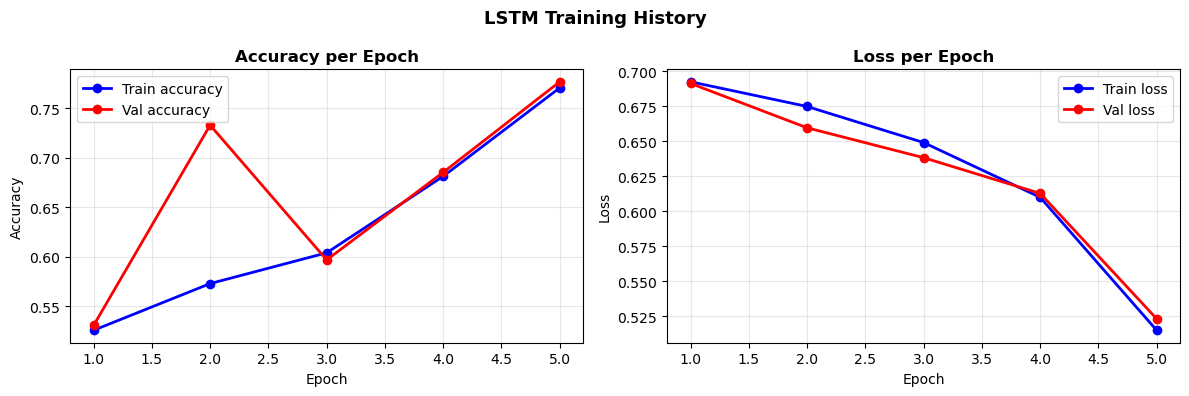

How to read these charts:
  ✓ HEALTHY   → Both blue and red lines move together (up for accuracy, down for loss)
  ✗ OVERFITTING → Train keeps improving but val plateaus or gets worse
  ✗ UNDERFITTING → Both lines are low and barely moving


In [10]:
# ── Plot training history ──

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))

epochs_ran = range(1, len(history_lstm.history['loss']) + 1)

# ── Accuracy plot ──
ax1.plot(epochs_ran, history_lstm.history['accuracy'],     'b-o', label='Train accuracy', linewidth=2)
ax1.plot(epochs_ran, history_lstm.history['val_accuracy'], 'r-o', label='Val accuracy',   linewidth=2)
ax1.set_title('Accuracy per Epoch', fontweight='bold')
ax1.set_xlabel('Epoch')
ax1.set_ylabel('Accuracy')
ax1.legend()
ax1.grid(True, alpha=0.3)

# ── Loss plot ──
ax2.plot(epochs_ran, history_lstm.history['loss'],     'b-o', label='Train loss', linewidth=2)
ax2.plot(epochs_ran, history_lstm.history['val_loss'], 'r-o', label='Val loss',   linewidth=2)
ax2.set_title('Loss per Epoch', fontweight='bold')
ax2.set_xlabel('Epoch')
ax2.set_ylabel('Loss')
ax2.legend()
ax2.grid(True, alpha=0.3)

plt.suptitle('LSTM Training History', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

print("How to read these charts:")
print("  ✓ HEALTHY   → Both blue and red lines move together (up for accuracy, down for loss)")
print("  ✗ OVERFITTING → Train keeps improving but val plateaus or gets worse")
print("  ✗ UNDERFITTING → Both lines are low and barely moving")


---
### 2.8 GRU — Build and Compare

GRU (Gated Recurrent Unit) works the same way as LSTM but uses fewer internal gates.  
The Keras code is almost identical — only one line changes.


In [12]:
# ── Build a GRU model ──
# Compare with the LSTM model above — the architecture is identical
# The ONLY difference: GRU(...) instead of LSTM(...)

model_gru = Sequential([
    Embedding(input_dim=VOCAB_SIZE, output_dim=EMBED_DIM, input_length=MAX_LEN),
    GRU(units=64, return_sequences=False),   # ← This is the only change from LSTM
    Dropout(0.3),
    Dense(1, activation='sigmoid')
])

model_gru.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])

# Build both models first so count_params() works correctly
model_gru.build(input_shape=(None, MAX_LEN))
model_lstm.build(input_shape=(None, MAX_LEN))

# Show parameter count comparison
lstm_params = model_lstm.count_params()
gru_params  = model_gru.count_params()
print(f"LSTM parameters : {lstm_params:,}")
print(f"GRU parameters  : {gru_params:,}")
print(f"Difference      : {lstm_params - gru_params:,} fewer parameters in GRU")
print("\nFewer parameters = GRU trains faster and uses less memory")

LSTM parameters : 673,089
GRU parameters  : 665,025
Difference      : 8,064 fewer parameters in GRU

Fewer parameters = GRU trains faster and uses less memory


In [13]:
# ── Train the GRU model ──

print("Training GRU model...")
history_gru = model_gru.fit(
    X_train_pad, y_train,
    epochs=5,
    batch_size=64,
    validation_split=0.2,
    callbacks=[EarlyStopping(monitor='val_loss', patience=2, restore_best_weights=True)],
    verbose=1
)

gru_loss, gru_acc = model_gru.evaluate(X_test_pad, y_test, verbose=0)
print(f"\nGRU Test Accuracy : {gru_acc*100:.1f}%")
print(f"LSTM Test Accuracy: {lstm_acc*100:.1f}%")
print("\n→ Similar performance, but GRU trained faster")


Training GRU model...
Epoch 1/5
313/313 ━━━━━━━━━━━━━━━━━━━━ 68s 166ms/step - accuracy: 0.5080 - loss: 0.6929 - val_accuracy: 0.5300 - val_loss: 0.6939
Epoch 2/5
313/313 ━━━━━━━━━━━━━━━━━━━━ 49s 155ms/step - accuracy: 0.5628 - loss: 0.6756 - val_accuracy: 0.5572 - val_loss: 0.6716
Epoch 3/5
313/313 ━━━━━━━━━━━━━━━━━━━━ 47s 151ms/step - accuracy: 0.6382 - loss: 0.6115 - val_accuracy: 0.6634 - val_loss: 0.6201
Epoch 4/5
313/313 ━━━━━━━━━━━━━━━━━━━━ 83s 155ms/step - accuracy: 0.6781 - loss: 0.5899 - val_accuracy: 0.5420 - val_loss: 0.6943
Epoch 5/5
313/313 ━━━━━━━━━━━━━━━━━━━━ 52s 167ms/step - accuracy: 0.6912 - loss: 0.5535 - val_accuracy: 0.8056 - val_loss: 0.4528

GRU Test Accuracy : 78.8%
LSTM Test Accuracy: 77.1%

→ Similar performance, but GRU trained faster


---
### 2.9 Bidirectional LSTM — Reading Both Ways

A regular LSTM reads left → right only.  
A **Bidirectional LSTM** runs two LSTMs simultaneously:
- One reads the sentence forwards (left → right)
- One reads the sentence backwards (right → left)

Their outputs are combined, giving the model context from **both directions**.  
This is especially useful for tasks like NER where what comes *after* a word is just as important as what comes *before* it.

```
Forwards:   "The  movie  was  not  bad"  →  →  →  →
Backwards:  "bad  not    was  movie The" ←  ←  ←  ←
                ↓ combined output ↓
```


In [14]:
# ── Build a Bidirectional LSTM ──

model_bidir = Sequential([
    Embedding(VOCAB_SIZE, EMBED_DIM, input_length=MAX_LEN),

    # Bidirectional wraps the LSTM and runs it in both directions
    # Output size doubles: 64 forward + 64 backward = 128
    Bidirectional(LSTM(64, return_sequences=False)),

    Dropout(0.3),
    Dense(1, activation='sigmoid')
])

model_bidir.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])

print("Bidirectional LSTM summary:")
model_bidir.summary()
print("\nNotice: output_dim = 128 (64 forward + 64 backward, concatenated)")


Bidirectional LSTM summary:


Model: "sequential_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ embedding_3 (Embedding)              │ ?                           │     0 (unbuilt) │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ bidirectional (Bidirectional)        │ ?                           │     0 (unbuilt) │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_3 (Dropout)                  │ ?                           │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_3 (Dense)                      │ ?                           │     0 (unbuilt) │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)


Notice: output_dim = 128 (64 forward + 64 backward, concatenated)


### 3.1 Does Embedding Size Matter?

The Embedding layer maps each word to a vector of numbers.  
- A larger vector (more dimensions) can capture more nuance about a word's meaning
- But it also means more parameters → slower training

Let's experiment: compare **32, 64, and 128** embedding dimensions.


In [15]:
# ── Experiment: test three different embedding sizes ──
# We train for just 2 epochs each to keep this quick

results = {}

for embed_dim in [32, 64, 128]:
    m = Sequential([
        Embedding(VOCAB_SIZE, embed_dim, input_length=MAX_LEN),
        LSTM(64),
        Dropout(0.3),
        Dense(1, activation='sigmoid')
    ])
    m.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])

    h = m.fit(
        X_train_pad, y_train,
        epochs=2,
        batch_size=64,
        validation_split=0.2,
        verbose=0
    )
    val_acc = h.history['val_accuracy'][-1]
    results[embed_dim] = val_acc
    print(f"  Embedding dim {embed_dim:>3} → val accuracy: {val_acc*100:.1f}%")

#print("\nDone ✓")


  Embedding dim  32 → val accuracy: 52.8%
  Embedding dim  64 → val accuracy: 55.0%
  Embedding dim 128 → val accuracy: 71.3%

Done ✓


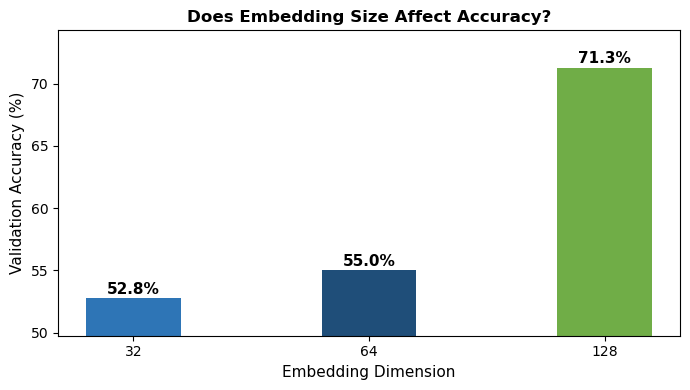

Observation: More dimensions → higher accuracy, but with diminishing returns.
64-128 is the sweet spot for most NLP tasks.


In [16]:
# ── Plot the embedding dimension comparison ──

dims = list(results.keys())
accs = [results[d] * 100 for d in dims]

plt.figure(figsize=(7, 4))
bars = plt.bar([str(d) for d in dims], accs,
               color=['#2E75B6', '#1F4E79', '#70AD47'], width=0.4)

for bar, acc in zip(bars, accs):
    plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.1,
             f'{acc:.1f}%', ha='center', va='bottom', fontweight='bold', fontsize=11)

plt.xlabel("Embedding Dimension", fontsize=11)
plt.ylabel("Validation Accuracy (%)", fontsize=11)
plt.title("Does Embedding Size Affect Accuracy?", fontweight='bold')
plt.ylim(min(accs) - 3, max(accs) + 3)
plt.tight_layout()
plt.show()

print("Observation: More dimensions → higher accuracy, but with diminishing returns.")
print("64-128 is the sweet spot for most NLP tasks.")


### 3.2 Stacked LSTM — Going Deeper

Just like a CNN can have multiple convolutional layers, an LSTM can have multiple recurrent layers stacked on top of each other.

- **First LSTM**: reads the raw words and produces a sequence of hidden states
- **Second LSTM**: reads that sequence and learns higher-level patterns

> **Critical rule:** All LSTM layers **except the last one** must have `return_sequences=True`.  
> Why? The next LSTM layer expects a full sequence as input, not just a single summary vector.


In [17]:
# ── Stacked LSTM: two LSTM layers on top of each other ──

model_stacked = Sequential([
    Embedding(VOCAB_SIZE, EMBED_DIM, input_length=MAX_LEN),

    # First LSTM — return_sequences=True because the next layer is ALSO an LSTM
    # It returns a hidden state for EVERY word (200 hidden states total)
    LSTM(64, return_sequences=True),
    Dropout(0.2),

    # Second LSTM — return_sequences=False because the next layer is Dense
    # It returns only the FINAL summary hidden state
    LSTM(32, return_sequences=False),
    Dropout(0.2),

    Dense(1, activation='sigmoid')
])

model_stacked.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])

print("Stacked LSTM architecture:")
model_stacked.summary()
print("\nKey: First LSTM has return_sequences=True → feeds a full sequence to the second LSTM")


Stacked LSTM architecture:


Model: "sequential_7"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ embedding_7 (Embedding)              │ ?                           │     0 (unbuilt) │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ lstm_5 (LSTM)                        │ ?                           │     0 (unbuilt) │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_7 (Dropout)                  │ ?                           │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ lstm_6 (LSTM)                        │ ?                           │     0 (unbuilt) │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_8 (Dropout)                  │ ?                           │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_7 (Dense)                      │ ?                           │     0 (unbuilt) │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)


Key: First LSTM has return_sequences=True → feeds a full sequence to the second LSTM


### 3.3 Predict Sentiment on Custom Reviews

Now let's use our trained LSTM to classify completely new reviews that it has never seen.


In [20]:
# ── Predict sentiment on custom text ──

def predict_sentiment(text, model, word_index, max_len=200):
    """
    Takes a plain English review and returns a prediction.
    Pipeline: lowercase -> split into words -> look up indices -> pad -> predict
    """
    words   = text.lower().split()
    indices = [word_index.get(w, 2) + 3 for w in words]  # +3 offset used by IMDB
    padded  = pad_sequences([indices], maxlen=max_len, padding='post', truncating='post')
    prob    = model.predict(padded, verbose=0)[0][0]
    label   = "POSITIVE" if prob > 0.5 else "NEGATIVE"
    return label, prob

# Test with a variety of reviews -- including some tricky ones
test_reviews = [
    "This film was absolutely brilliant. I loved every minute of it.",
    "Terrible movie. Boring, slow, and a complete waste of time.",
    "The movie was not bad at all. I was pleasantly surprised.",
    "I did not enjoy this film. Nothing made sense.",
    "An average film, nothing special but not unwatchable either.",
]

print("SENTIMENT PREDICTIONS")
print("=" * 60)
for review in test_reviews:
    label, prob = predict_sentiment(review, model_lstm, word_index)
    short = review[:50] + "..." if len(review) > 50 else review
    print(f"  {label}  ({prob:.0%} confidence)")
    print(f"  Review: '{short}'")
    print()

SENTIMENT PREDICTIONS
  POSITIVE  (82% confidence)
  Review: 'This film was absolutely brilliant. I loved every ...'

  NEGATIVE  (28% confidence)
  Review: 'Terrible movie. Boring, slow, and a complete waste...'

  NEGATIVE  (28% confidence)
  Review: 'The movie was not bad at all. I was pleasantly sur...'

  POSITIVE  (82% confidence)
  Review: 'I did not enjoy this film. Nothing made sense.'

  NEGATIVE  (28% confidence)
  Review: 'An average film, nothing special but not unwatchab...'



> **Notice:** The LSTM correctly handles tricky negations like *"not bad at all"* (positive) because it reads the words **in order** and understands the context of "not".  
> A TF-IDF model might flag this as negative because it sees the word "bad".


##  Named Entity Recognition with spaCy

**NER (Named Entity Recognition)** is a **Many-to-Many** task.  
For every word in the input, the model outputs a label:

| Label | Meaning | Example |
|-------|---------|---------|
| PERSON | People's names | Elon Musk |
| ORG | Organisations | WHO, Google, Tesla |
| GPE | Countries / cities / states | Nigeria, Lagos, California |
| DATE | Dates and times | March 12, 2024 |
| MONEY | Monetary values | $50 million |
| O | No entity (ordinary word) | the, was, and |

We use **spaCy** — a pre-trained NLP library. No training required — it already knows how to find entities.


In [26]:
# Download the spaCy English model — run this once only
import subprocess
subprocess.run(["python", "-m", "spacy", "download", "en_core_web_sm"], check=True)
#print("spaCy model downloaded successfully!")

CompletedProcess(args=['python', '-m', 'spacy', 'download', 'en_core_web_sm'], returncode=0)

In [27]:
# ── Named Entity Recognition with spaCy ──

import spacy

nlp = spacy.load("en_core_web_sm")

test_sentences = [
    "John works at Google in Lagos, Nigeria.",
    "The WHO and UNICEF announced a new vaccine programme in Abuja on March 12, 2024.",
    "Elon Musk founded Tesla in California and SpaceX in Texas.",
    "The Nigerian government allocated $200 million to healthcare in 2023.",
]

print("NAMED ENTITY RECOGNITION RESULTS")
print("=" * 55)

for sentence in test_sentences:
    doc = nlp(sentence)
    print(f"\nSentence: {sentence}")
    print(f"  {'Entity':<25} {'Type'}")
    print(f"  {'-'*40}")
    if doc.ents:
        for ent in doc.ents:
            print(f"  {ent.text:<25} {ent.label_}")
    else:
        print("  (no entities found)")

NAMED ENTITY RECOGNITION RESULTS

Sentence: John works at Google in Lagos, Nigeria.
  Entity                    Type
  ----------------------------------------
  John                      PERSON
  Google                    ORG
  Lagos                     GPE
  Nigeria                   GPE

Sentence: The WHO and UNICEF announced a new vaccine programme in Abuja on March 12, 2024.
  Entity                    Type
  ----------------------------------------
  WHO                       ORG
  UNICEF                    ORG
  Abuja                     GPE
  March 12, 2024            DATE

Sentence: Elon Musk founded Tesla in California and SpaceX in Texas.
  Entity                    Type
  ----------------------------------------
  Elon Musk                 PERSON
  Tesla                     ORG
  California                GPE
  SpaceX                    GPE
  Texas                     GPE

Sentence: The Nigerian government allocated $200 million to healthcare in 2023.
  Entity              

> **Output explanation:** SpaCy correctly identifies:
> - **People** (John, Elon Musk) as PERSON
> - **Organisations** (Google, WHO, UNICEF, Tesla, SpaceX) as ORG
> - **Places** (Lagos, Nigeria, California, Texas, Abuja) as GPE
> - **Dates** (March 12, 2024, 2023) as DATE
> - **Money** ($200 million) as MONEY
>
> Notice that *"not"* in Cells 15 and 21 required manual maths — here the library does everything for you.


In [28]:
# ── Summary: count all entity types found across all sentences ──

from collections import Counter

all_text = " ".join(test_sentences)
doc = nlp(all_text)

entity_counts = Counter(ent.label_ for ent in doc.ents)

print("All entities found:")
print(f"  {'Entity Text':<25} {'Type'}")
print(f"  {'-'*38}")
for ent in doc.ents:
    print(f"  {ent.text:<25} {ent.label_}")

print("\nEntity type breakdown:")
for etype, count in entity_counts.most_common():
    print(f"  {etype:<12} : {count} found")


All entities found:
  Entity Text               Type
  --------------------------------------
  John                      PERSON
  Google                    ORG
  Lagos                     GPE
  Nigeria                   GPE
  WHO                       ORG
  UNICEF                    ORG
  Abuja                     GPE
  March 12, 2024            DATE
  Elon Musk                 PERSON
  Tesla                     ORG
  California                GPE
  SpaceX                    GPE
  Texas                     GPE
  Nigerian                  NORP
  $200 million              MONEY
  2023                      DATE

Entity type breakdown:
  GPE          : 6 found
  ORG          : 4 found
  PERSON       : 2 found
  DATE         : 2 found
  NORP         : 1 found
  MONEY        : 1 found


---
## Topic Modeling with LDA

**Topic modeling** discovers hidden themes in a collection of documents — completely automatically, with **no labels needed**.  
This is **unsupervised learning** applied to text.

**LDA (Latent Dirichlet Allocation)** works with two assumptions:
1. Each document is a **mixture of topics** (a health article might be 70% health, 30% technology)
2. Each topic is a **distribution over words** (a "health" topic has high probability for words like *vaccine*, *hospital*, *patient*)

We tell LDA **how many topics** to look for — and it discovers what they are from the words themselves.


In [29]:
# ── Prepare documents for LDA ──

from sklearn.feature_extraction.text import CountVectorizer
from sklearn.decomposition import LatentDirichletAllocation

# Two groups of documents from clearly different domains
documents = [
    # Health documents
    "Vaccination reduces disease transmission and protects community immunity.",
    "The hospital reported an increase in patients with respiratory infections.",
    "Doctors recommend annual health checkups and preventive care for all adults.",
    "New research shows vaccines are highly effective against infectious diseases.",
    "Community health workers are key to delivering primary healthcare in rural areas.",

    # Technology documents
    "Machine learning algorithms improve software performance and automate tasks.",
    "Cloud computing enables scalable data storage and processing for businesses.",
    "Artificial intelligence is transforming industries through automation.",
    "Deep learning models require large datasets and significant computing power.",
    "Software developers use Python and TensorFlow to build AI applications.",
]

# Convert documents to a word-count matrix
# (how many times each word appears in each document)
vectorizer     = CountVectorizer(stop_words='english', max_features=500)
doc_term_matrix = vectorizer.fit_transform(documents)

print(f"Documents      : {len(documents)}")
print(f"Vocabulary size: {len(vectorizer.get_feature_names_out())}")
print("\nReady for LDA ✓")


Documents      : 10
Vocabulary size: 71

Ready for LDA ✓


In [30]:
# ── Run LDA to discover topics ──

NUM_TOPICS = 2    # We expect 2 topics: health and technology
TOP_WORDS  = 8    # Show the top 8 words for each topic

lda = LatentDirichletAllocation(
    n_components=NUM_TOPICS,
    random_state=42,
    max_iter=20
)
lda.fit(doc_term_matrix)

vocab = vectorizer.get_feature_names_out()

print("LDA TOPICS DISCOVERED")
print("=" * 50)

for topic_idx, topic_weights in enumerate(lda.components_):
    top_indices = topic_weights.argsort()[-TOP_WORDS:][::-1]
    top_words   = [vocab[i] for i in top_indices]
    print(f"\nTopic {topic_idx + 1} — top words:")
    print(f"  {', '.join(top_words)}")

print("\n→ You interpret the topics based on the words.")
print("  Topic with 'vaccine, hospital, patients' = Health")
print("  Topic with 'AI, software, cloud' = Technology")


LDA TOPICS DISCOVERED

Topic 1 — top words:
  learning, software, computing, power, deep, datasets, models, require

Topic 2 — top words:
  community, health, computing, rural, key, healthcare, delivering, primary

→ You interpret the topics based on the words.
  Topic with 'vaccine, hospital, patients' = Health
  Topic with 'AI, software, cloud' = Technology


In [31]:
# ── Show which topic each document belongs to ──

doc_topic_dist = lda.transform(doc_term_matrix)

print("DOCUMENT → TOPIC DISTRIBUTION")
print("=" * 65)
print(f"  {'Document (first 50 chars)':<52} {'Topic 1':>7}  {'Topic 2':>7}  Dominant")
print(f"  {'-'*65}")

for doc, dist in zip(documents, doc_topic_dist):
    short    = doc[:50] + "..."
    dominant = "Topic 1" if dist[0] > dist[1] else "Topic 2"
    print(f"  {short:<52} {dist[0]:>6.2f}   {dist[1]:>6.2f}   {dominant}")

print("\n→ Health documents should cluster toward one topic,")
print("  technology documents toward the other.")


DOCUMENT → TOPIC DISTRIBUTION
  Document (first 50 chars)                            Topic 1  Topic 2  Dominant
  -----------------------------------------------------------------
  Vaccination reduces disease transmission and prote...   0.06     0.94   Topic 2
  The hospital reported an increase in patients with...   0.07     0.93   Topic 2
  Doctors recommend annual health checkups and preve...   0.94     0.06   Topic 1
  New research shows vaccines are highly effective a...   0.94     0.06   Topic 1
  Community health workers are key to delivering pri...   0.05     0.95   Topic 2
  Machine learning algorithms improve software perfo...   0.94     0.06   Topic 1
  Cloud computing enables scalable data storage and ...   0.06     0.94   Topic 2
  Artificial intelligence is transforming industries...   0.09     0.91   Topic 2
  Deep learning models require large datasets and si...   0.95     0.05   Topic 1
  Software developers use Python and TensorFlow to b...   0.94     0.06   Topic 1


> **How to read the results:** Each row shows a document and its probability of belonging to Topic 1 vs Topic 2.  
> A score of 0.90 for Topic 1 means the model is 90% confident this document is about Topic 1.  
>
> **In practice** you would use thousands of documents and maybe 10-50 topics — LDA will discover themes you might not have expected.


---
## Final Comparison


In [32]:
# ── Final comparison: all models side by side ──

print("=" * 55)
print("     FINAL MODEL COMPARISON — IMDB SENTIMENT")
print("=" * 55)
print(f"  TF-IDF + Logistic Regression  : {baseline_acc*100:.1f}%  (no word order)")
print(f"  LSTM                          : {lstm_acc*100:.1f}%  (reads sequence)")
print(f"  GRU                           : {gru_acc*100:.1f}%  (faster, similar)")
print("=" * 55)
print("\nKey takeaways:")
print("  1. TF-IDF is a strong, fast baseline — always build one first")
print("  2. LSTM/GRU understand word order and context")
print("  3. GRU trains faster than LSTM with comparable accuracy")
print("  4. More epochs and tuning would push LSTM/GRU higher")
print("  5. Bidirectional LSTM gives context from both directions")


     FINAL MODEL COMPARISON — IMDB SENTIMENT
  TF-IDF + Logistic Regression  : 88.4%  (no word order)
  LSTM                          : 77.1%  (reads sequence)
  GRU                           : 78.8%  (faster, similar)

Key takeaways:
  1. TF-IDF is a strong, fast baseline — always build one first
  2. LSTM/GRU understand word order and context
  3. GRU trains faster than LSTM with comparable accuracy
  4. More epochs and tuning would push LSTM/GRU higher
  5. Bidirectional LSTM gives context from both directions


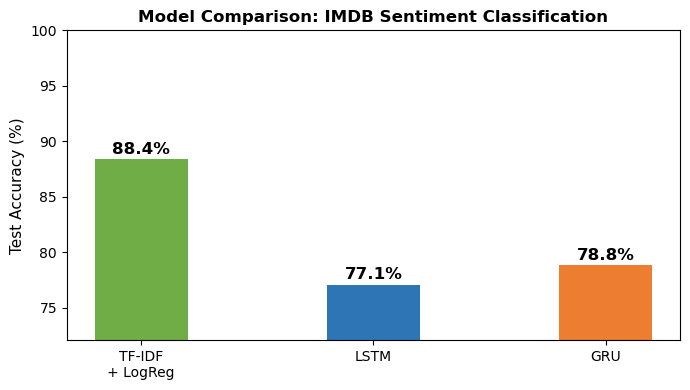

In [33]:
# ── Summary bar chart ──

models     = ['TF-IDF\n+ LogReg', 'LSTM', 'GRU']
accuracies = [baseline_acc * 100, lstm_acc * 100, gru_acc * 100]
colors     = ['#70AD47', '#2E75B6', '#ED7D31']

plt.figure(figsize=(7, 4))
bars = plt.bar(models, accuracies, color=colors, width=0.4)

for bar, acc in zip(bars, accuracies):
    plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.2,
             f'{acc:.1f}%', ha='center', va='bottom', fontsize=12, fontweight='bold')

plt.ylabel("Test Accuracy (%)", fontsize=11)
plt.title("Model Comparison: IMDB Sentiment Classification", fontweight='bold')
plt.ylim(min(accuracies) - 5, 100)
plt.tight_layout()
plt.show()
